In [1]:
#installations

!pip install yfinance statsmodels scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.1/127.1 kB 1.2 MB/s eta 0:00:00 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.9/411.9 kB 2.8 MB/s eta 0:00:002.9 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 7.0 MB/s eta 0:00:007.0 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.6/184.6 kB 22.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.9/152.9 kB 16.5 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15549 sha256=aec2553bf5fbe9e026804ed13f3e2260bf83994b05609ec30010cad9ccce65de
  Stored in directory: /home/mca/.cache/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking
  Attempting uninstall: certifi
    Found existing installation: certifi 2023.5.7
    Uninstalling certifi-2023.5.

In [3]:
import yfinance as yf
yf.set_tz_cache_location(None)
 

In [12]:
#download data

import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]

data = yf.download(tickers, start="2015-01-01", end="2025-01-01", group_by="ticker", threads=False)

# We'll use AAPL for modeling demo
df = data["AAPL"].copy()

df.head()

# Force business-day frequency
df = df.asfreq("B")

# Forward-fill missing market days
df = df.ffill()



[*********************100%***********************]  5 of 5 completed


In [13]:
#Data Cleaning


df = df.sort_index()
df = df[~df.index.duplicated()]
df = df.ffill()
df = df.dropna()

# Basic validation
assert (df["Close"] > 0).all()
assert (df["Volume"] >= 0).all()

df.info()

# Force business-day frequency
df = df.asfreq("B")

# Forward-fill missing market days
df = df.ffill()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2608 entries, 2015-01-02 to 2024-12-31
Freq: B
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2608 non-null   float64
 1   High    2608 non-null   float64
 2   Low     2608 non-null   float64
 3   Close   2608 non-null   float64
 4   Volume  2608 non-null   float64
dtypes: float64(5)
memory usage: 122.2 KB


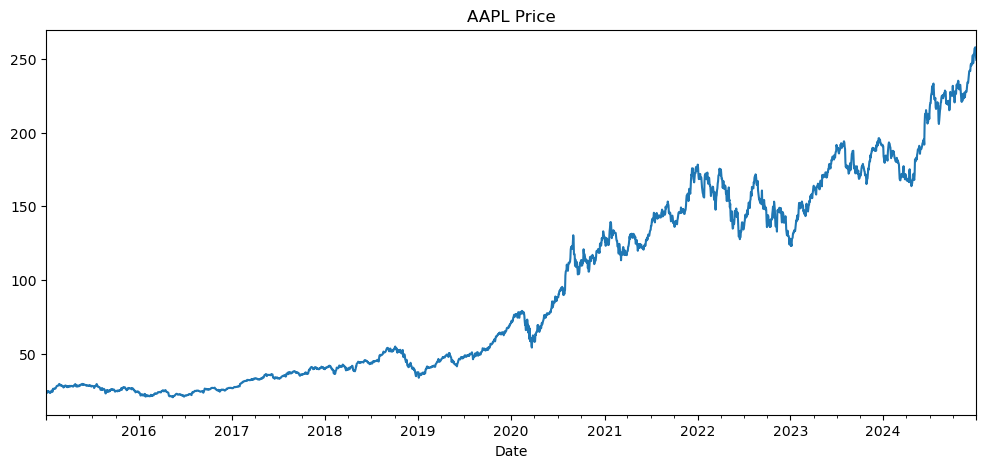

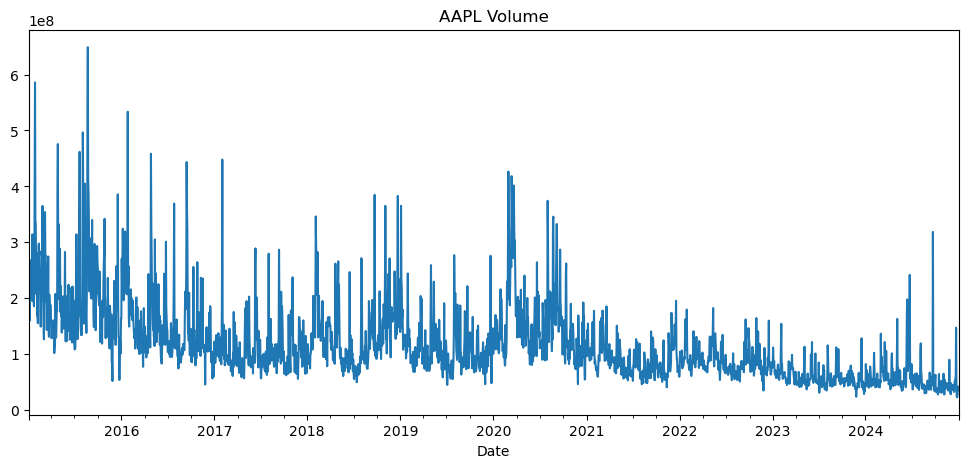

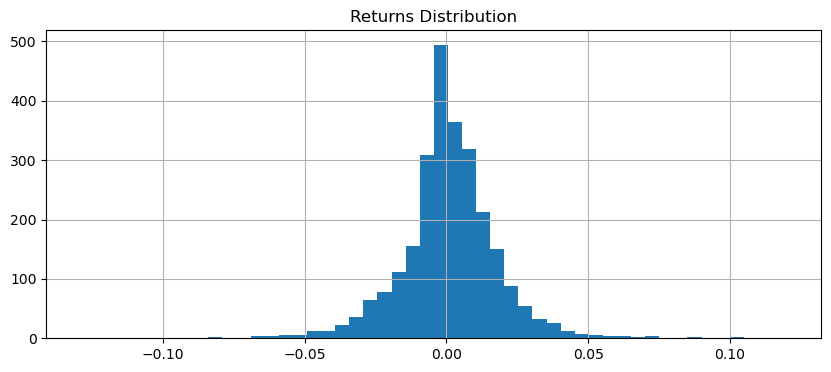

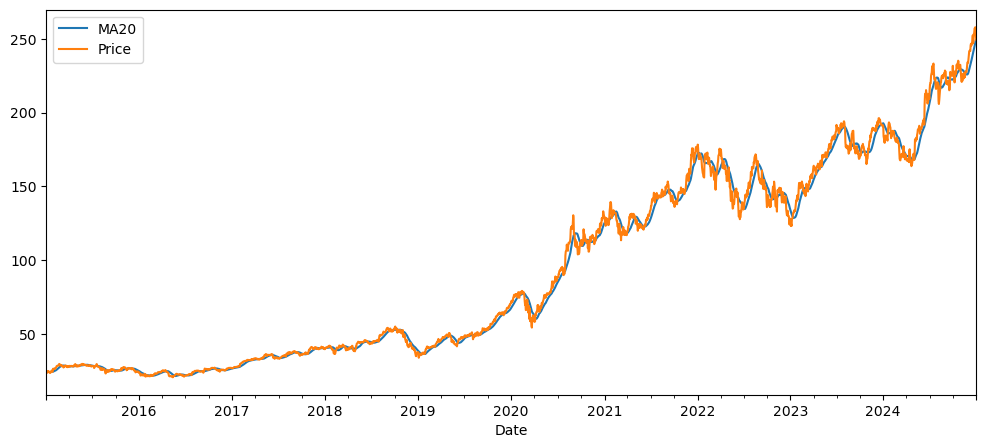

In [14]:
#EDA

import matplotlib.pyplot as plt

# Price
df["Close"].plot(figsize=(12,5), title="AAPL Price")
plt.show()

# Volume
df["Volume"].plot(figsize=(12,5), title="AAPL Volume")
plt.show()

# Returns
returns = df["Close"].pct_change()

returns.hist(bins=50, figsize=(10,4))
plt.title("Returns Distribution")
plt.show()

# Rolling stats
df["Close"].rolling(20).mean().plot(label="MA20", figsize=(12,5))
df["Close"].plot(label="Price")
plt.legend()
plt.show()


In [15]:
#Feature Engineering

df_feat = df.copy()

df_feat["return_1d"] = df_feat["Close"].pct_change()
df_feat["return_5d"] = df_feat["Close"].pct_change(5)

df_feat["ma_5"] = df_feat["Close"].rolling(5).mean()
df_feat["ma_20"] = df_feat["Close"].rolling(20).mean()

df_feat["volatility_20"] = df_feat["return_1d"].rolling(20).std()

df_feat["lag_1"] = df_feat["Close"].shift(1)
df_feat["lag_5"] = df_feat["Close"].shift(5)

# Target: next day close
df_feat["target"] = df_feat["Close"].shift(-1)

df_feat = df_feat.dropna()

df_feat.head()


Price,Open,High,Low,Close,Volume,return_1d,return_5d,ma_5,ma_20,volatility_20,lag_1,lag_5,target
Date,,,,,,,,,,,,,
2015-01-30,26.248293,26.603000,25.904671,25.973396,334982000.0,-0.014634,0.036998,25.432912,24.491278,0.023751,26.359138,25.046728,26.299284
2015-02-02,26.170704,26.418998,25.733971,26.299284,250956400.0,0.012547,0.048895,25.678104,24.628505,0.022590,25.973396,25.073326,26.303722
2015-02-03,26.270468,26.401266,26.073163,26.303722,207662800.0,0.000169,0.087136,26.099762,24.765843,0.022589,26.299284,24.195433,26.505455
2015-02-04,26.270462,26.716063,26.228340,26.505455,280598800.0,0.007669,0.036857,26.288199,24.896752,0.022511,26.303722,25.563269,26.694641
2015-02-05,26.712445,26.759186,26.541070,26.694641,168984800.0,0.007138,0.012728,26.355300,24.991230,0.021145,26.505455,26.359138,26.469845


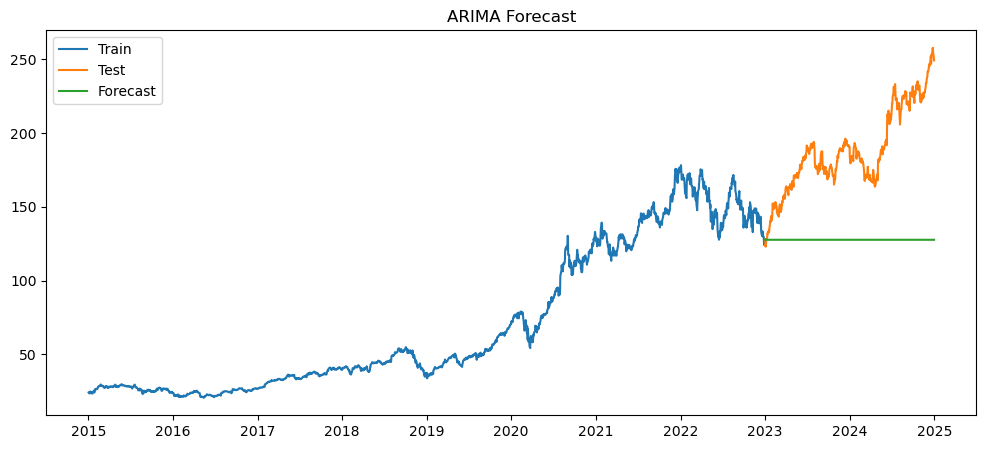

In [16]:
#ARIMA Model

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Force business-day frequency
df = df.asfreq("B")
df = df.ffill()

series = df["Close"]

# Train/test split
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]


# Fit ARIMA (simple order, explain in report you tried few)
model = ARIMA(train, order=(5,1,0))
fit = model.fit()

forecast = fit.forecast(steps=len(test))

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()


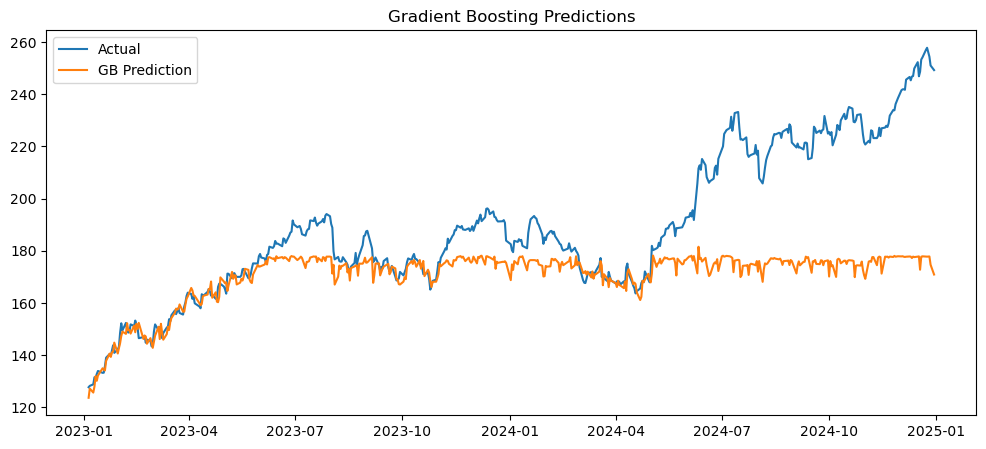

In [10]:
#Gradient Boosting Model

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

features = [
    "return_1d","return_5d","ma_5","ma_20",
    "volatility_20","lag_1","lag_5","Volume"
]

X = df_feat[features]
y = df_feat["target"]

# Time-based split
split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

model_gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train, y_train)

pred_gb = model_gb.predict(X_test)

# Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, pred_gb, label="GB Prediction")
plt.legend()
plt.title("Gradient Boosting Predictions")
plt.show()


In [17]:
#Evaluation

def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

# ARIMA metrics
arima_rmse, arima_mae, arima_mape = metrics(test, forecast)

# GB metrics
gb_rmse, gb_mae, gb_mape = metrics(y_test, pred_gb)

results = pd.DataFrame({
    "Model": ["ARIMA", "Gradient Boosting"],
    "RMSE": [arima_rmse, gb_rmse],
    "MAE": [arima_mae, gb_mae],
    "MAPE": [arima_mape, gb_mape]
})

results


,Model,RMSE,MAE,MAPE
0,ARIMA,66.778268,60.572424,30.652214
1,Gradient Boosting,28.505086,18.670444,8.644381


In [ ]:
#Save Outputs

# results.to_csv("model_comparison.csv")
# plt.savefig("prediction_plot.png")